In [14]:
# Load the Kedro IPython extension
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

In [16]:
df = catalog.load("master_trx_customer_tct").to_pandas()

[06/28/25 17:11:31] INFO     Loading data from master_trx_customer_tct                          ]8;id=367162;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=506403;file:///Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/python3.11/site-packages/kedro/io/data_catalog.py#403\403]8;;\
                             (PolarsParquetDataset)...                                                             

In [17]:
df["revenue"] = df["c_yearly_network_volumen"] * df["c_yearly_margin_per_liter"]
df["log_revenue"] = np.log(df["revenue"] + 1)

df["zscore_revenue"] = zscore(df["log_revenue"], nan_policy="omit")

cond_zscore = df["zscore_revenue"].abs() > 2.5

df["is_outlier"] = cond_zscore

                    WARNING  /Users/Carlos_Davalos/Projects/B2B_COPEC/b2b-pricing-model/.venv/lib/p ]8;id=151224;file:///Users/Carlos_Davalos/.local/share/uv/python/cpython-3.11.10-macos-aarch64-none/lib/python3.11/warnings.py\warnings.py]8;;\:]8;id=853349;file:///Users/Carlos_Davalos/.local/share/uv/python/cpython-3.11.10-macos-aarch64-none/lib/python3.11/warnings.py#110\110]8;;\
                             ython3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:                 
                             invalid value encountered in log                                                      
                               result = getattr(ufunc, method)(*inputs, **kwargs)                                  
                                                                                                                   

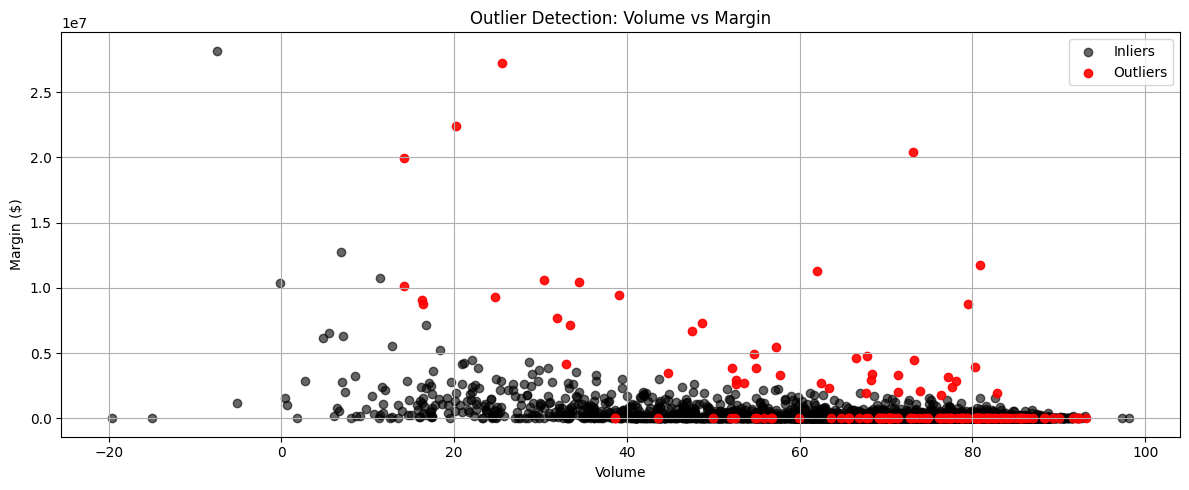

In [18]:
# Plot original data, color by outlier status
plt.figure(figsize=(12, 5))
plt.scatter(
    df["c_yearly_margin_per_liter"][~df["is_outlier"]],
    df["c_yearly_network_volumen"][~df["is_outlier"]],
    color="black",
    label="Inliers",
    alpha=0.6,
)
plt.scatter(
    df["c_yearly_margin_per_liter"][df["is_outlier"]],
    df["c_yearly_network_volumen"][df["is_outlier"]],
    color="red",
    label="Outliers",
    alpha=0.9,
)
plt.xlabel("Volume")
plt.ylabel("Margin ($)")
plt.title("Outlier Detection: Volume vs Margin")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

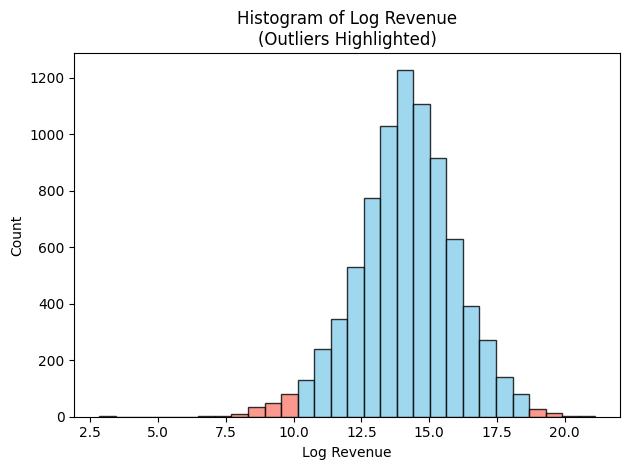

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Drop NaNs just in case
df_clean = df[~df["log_revenue"].isna()]

# Separate the values
all_data = df_clean["log_revenue"].values
outlier_mask = df_clean["is_outlier"].values

# Safety check
if len(all_data) == 0:
    raise ValueError("No valid data in 'log_revenue' after removing NaNs.")

# Define bins
bins = np.histogram_bin_edges(all_data, bins=30)

# Compute histogram for all data and outliers only
counts, bin_edges = np.histogram(all_data, bins=bins)
outlier_counts, _ = np.histogram(all_data[outlier_mask], bins=bins)

# Bin centers for plotting
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bar_colors = ["salmon" if out > 0 else "skyblue" for out in outlier_counts]

# Plot bars
plt.bar(
    bin_centers,
    counts,
    width=np.diff(bin_edges),
    color=bar_colors,
    edgecolor="black",
    alpha=0.8,
)

# Labels
plt.xlabel("Log Revenue")
plt.ylabel("Count")
plt.title("Histogram of Log Revenue\n(Outliers Highlighted)")
plt.tight_layout()
plt.show()


In [20]:
df["is_outlier"].value_counts(dropna=False)


is_outlier
False    7884
True      146
Name: count, dtype: int64

In [21]:
df

,customer_id,c_yearly_volumen,c_yearly_charged_amount,c_yearly_margin,c_yearly_trx_count,c_yearly_regions_count,c_yearly_stations_count,c_days_since_last_trx,c_yearly_avg_volume_per_trx,c_yearly_charged_amount_per_liter,...,c_monthly_avg_perc_of_volume_potential,c_monthly_std_perc_of_volume_potential,c_annualized_network_monthly_volume,c_weighted_competitive_index,c_tct_yearly_perc_volume,revenue,log_revenue,log_c_yearly_margin,zscore_revenue,is_outlier
0,id_10002106,4548.93,5.106582e+06,3.729908e+05,5,3,3,362,909.786000,1122.589708,...,1.000000,NaN,5.458716e+04,6.537076,1.000000,3.729908e+05,12.829312,12.829312,-0.726296,False
1,id_10003969,467554.74,4.719009e+08,3.197261e+07,945,12,43,0,494.766921,1009.295615,...,0.580445,0.262580,4.675547e+05,6.056923,1.000000,3.197261e+07,17.280390,17.280390,1.715619,False
2,id_10005710,12552.41,1.329893e+07,1.014468e+06,41,2,6,3,306.156341,1059.472484,...,0.453216,0.357993,1.673655e+04,10.536199,1.000000,1.014468e+06,13.829876,13.829876,-0.177374,False
3,id_10020444,2453.95,2.423510e+06,1.885358e+05,32,9,17,101,76.685937,987.595509,...,0.506855,0.358764,7.361850e+03,14.162420,1.000000,1.885358e+05,12.147048,12.147048,-1.100594,False
4,id_10024919,7220.59,7.359821e+06,5.661447e+05,75,2,2,3,96.274533,1019.282496,...,0.682086,0.169226,7.220590e+03,17.281488,1.000000,5.661447e+05,13.246607,13.246607,-0.497363,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8025,idg_006285,439265.27,4.203313e+08,2.038617e+07,1205,1,18,0,364.535494,956.896381,...,0.615607,0.284633,4.392653e+05,41.989519,0.184489,1.105005e+08,18.520530,16.830367,2.395975,False
8026,idg_006286,425951.29,4.160694e+08,1.998770e+07,1986,6,59,0,214.476984,976.800537,...,0.737284,0.170892,4.259513e+05,12.801910,0.341764,5.848395e+07,17.884263,16.810628,2.046911,False
8027,idg_006287,12827.58,1.254132e+07,7.677431e+05,164,2,17,3,78.216951,977.683866,...,0.708824,0.221998,1.539310e+04,44.782736,0.007906,9.711355e+07,18.391392,13.551212,2.325128,False
8028,idg_006288,1345145.03,1.250716e+09,2.160269e+07,793,4,6,0,1696.273682,929.799909,...,0.739993,0.156402,1.345145e+06,51.783751,1.000000,2.160269e+07,16.888328,16.888328,1.500530,False
